<a id="inicio"></a>

# Dog Breed Classification with Deep Learning

## Objective

Build, train, and compare three image classifiers on a 74-class fine-grained dog-breed recognition task, progressing from a vanilla CNN to hyperparameter tuning, transfer learning (InceptionV3 with fine-tuning), and data augmentation.

## Methodology

- **Dataset**: 12,891 images across 74 dog breeds, with dedicated train/validation/test splits
- **Preprocessing**: Optimized `tf.data.Dataset` pipelines for efficient image loading
- **Model 1 — CNN from scratch**: A VGG16-inspired convolutional network trained from random initialization
- **Model 2 — Hyperparameter-tuned CNN**: Adds Dropout and an extra convolutional block
- **Model 3 — Transfer learning**: InceptionV3 with frozen convolutional base and a trainable classifier head
- **Model 4 — Data augmentation**: Horizontal/vertical flips and contrast adjustment applied to the scratch CNN
- **Evaluation**: Accuracy on validation and test sets, confusion matrix per model

<div class="alert alert-block alert-info">

### ℹ️ Note on cell outputs

The cell outputs visible in this notebook were captured during the **original run** and are shown here as a visual reference for portfolio review. Some artifacts may still appear in Spanish because the outputs predate the English code translation.

**To re-run locally:**

1. This notebook was originally developed in Google Colab with GPU acceleration — re-running on CPU will be very slow.
2. Mount Google Drive (or adapt the paths) and download the dog-breed dataset via the provided link.
3. Install dependencies: TensorFlow 2.x, NumPy, pandas, matplotlib, scikit-learn (for confusion matrices).
4. Execute cells top-to-bottom.

</div>

---

In [ ]:
import glob
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from PIL import Image
import seaborn as sns
import sklearn.metrics as metrics
import sklearn.metrics as confusion_matrix
from sklearn.model_selection import train_test_split

---

## Introduction

This project simulates a complete image classification workflow using Deep Learning. The steps follow a typical DL recipe and can serve as a template for similar classification problems:

1. **Dataset** — Download and preview
2. **Preprocessing** — Prepare images for training
3. **Baseline CNN** — Build a convolutional network from scratch
4. **Hyperparameter tuning** — Improve the baseline via architectural changes and regularization
5. **Pre-trained model (fine-tuning)** — Apply transfer learning with InceptionV3
6. **Data augmentation** — Augment the training distribution
7. **Conclusion** — Compare results and pick a production-ready model

Each model's performance is evaluated through accuracy metrics and a confusion matrix over the 74 breed classes.

*Note: if running in Google Colab, the next cell mounts Google Drive so all downloaded files and intermediate artifacts persist across sessions.*

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
cd drive/MyDrive/

/content/drive/MyDrive


In [ ]:
ls

 2014_11_24_SPO_BA_Engineering_and_Management_en.pdf
'Amazon DES'/
'Amazon Lux'/
'Artifficial Intelligence and Analytics'/
'Asignaturas UGR.gsheet'
 BIS/
'Carta Motivación .gdoc'
 CIDAEN/
'Colab Notebooks'/
 CV/
'data science'/
 Devoluciones_Enero2022/
 Document.docx
'Documentos Necesarios.gdoc'
 Documents/
 dog-dataset/
 dog-images.zip
 global-sports-equipment-retail-141226.pdf
'Graduation Documents'/
'Infographics 3.gslides'
'Intercultural Studies'/
'Job Seeking'/
"Justificant de l'operació realitzada.pdf"
 Language_learning/
'Last semester'/
'London Expenses'/
 Luis_Nunez_CV.pdf
 __MACOSX/
'Mark Sheet in English 21-1-2022 18.38.20.pdf'
 mc5-m2-capstone.7z
'Objetivos Profesionales.gdoc'
 Old/
'Personal stuff'/
 PQM/
'Prioridad Asignaturas.gdoc'
'Project Files'/
'questions exam.pdf'
 rtij_angl.xlsx
 SQL/
 study_id24943_global-sports-market.pdf
 Thesis/
 ticket-20210207100546.pdf
 Tickets/
'Tracking Master.gsheet'
 Training/
 UFSC/
 UNI/
'Untitled document (10).gdoc'
'Untitled docume

---

# Dataset

The dataset contains images of 74 different dog breeds — 12,891 images total. The task is to learn a classifier that identifies the breed from a single image. The dataset is downloadable in the next cell.

In [ ]:
!wget 'https://pruebasaluuclm-my.sharepoint.com/:u:/g/personal/fernando_rubio_uclm_es/ESpljekZA9dAgxsfc3qIDvEBMT76g8rPDOpMwgDwHe0BKw?download=1'
!mv 'ESpljekZA9dAgxsfc3qIDvEBMT76g8rPDOpMwgDwHe0BKw?download=1' dog-images.zip
!unzip -q dog-images.zip

--2025-05-15 06:52:47--  https://pruebasaluuclm-my.sharepoint.com/:u:/g/personal/fernando_rubio_uclm_es/ESpljekZA9dAgxsfc3qIDvEBMT76g8rPDOpMwgDwHe0BKw?download=1
Resolving pruebasaluuclm-my.sharepoint.com (pruebasaluuclm-my.sharepoint.com)... 13.107.136.10, 13.107.138.10, 2620:1ec:8f8::10, ...
Connecting to pruebasaluuclm-my.sharepoint.com (pruebasaluuclm-my.sharepoint.com)|13.107.136.10|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: /personal/fernando_rubio_uclm_es/Documents/dog-dataset.zip?ga=1 [following]
--2025-05-15 06:52:48--  https://pruebasaluuclm-my.sharepoint.com/personal/fernando_rubio_uclm_es/Documents/dog-dataset.zip?ga=1
Reusing existing connection to pruebasaluuclm-my.sharepoint.com:443.
HTTP request sent, awaiting response... 200 OK
Length: 498626796 (476M) [application/x-zip-compressed]
Saving to: ‘ESpljekZA9dAgxsfc3qIDvEBMT76g8rPDOpMwgDwHe0BKw?download=1’

ESpljekZA9dAgxsfc3q 100%[===================>] 475.53M  52.0MB/s    in 13s     



The archive `dog-images.zip` auto-extracts into `dog-dataset/` with the structure:

```
dog-dataset/
    test.csv
    train.csv
    valid.csv
    dog-images/
        Afghan_hound/
        African_hunting_dog/
        ...
```

Inside `dog-dataset/`:

* **`dog-images/`** — All images, organized by breed (74 subfolders, one per class).
* **`train.csv`** — Training set (8,992 images). Two columns: `label` (breed) and `path` (relative path inside `dog-images/`).
* **`valid.csv`** — Validation set (1,894 images). Same format.
* **`test.csv`** — Test set (2,005 images). Same format.

A few sample images from the dataset:

In [ ]:
def show_images(img_paths):
    fig=plt.figure(figsize=(20, 20))
    index = np.random.randint(len(img_paths), size=100)
    for i in range(100):
        fig.add_subplot(10, 10, i+1)
        plt.axis('off')
        img = Image.open(img_paths[index[i]])
        plt.imshow(img)
    plt.show()

files = [f for f in glob.glob("dog-dataset/dog-images/**/*.jpg", recursive=True)]
show_images(files)

Output hidden; open in https://colab.research.google.com to view.

Two characteristics that make the problem harder:

- Images have **different resolutions**.
- Images often contain **unrelated objects** alongside the dog.

Build a `classes` list holding all 74 breed names — these will be the model output labels.

In [ ]:
classes = [f.split('/')[-1] for f in glob.glob("dog-dataset/dog-images/**")]
classes

['Pekinese',
 'Afghan_hound',
 'beagle',
 'bluetick',
 'black-and-tan_coonhound',
 'Walker_hound',
 'borzoi',
 'Norwegian_elkhound',
 'American_Staffordshire_terrier',
 'Irish_terrier',
 'Yorkshire_terrier',
 'Lakeland_terrier',
 'Sealyham_terrier',
 'cairn',
 'Dandie_Dinmont',
 'Scotch_terrier',
 'soft-coated_wheaten_terrier',
 'West_Highland_white_terrier',
 'Lhasa',
 'golden_retriever',
 'Labrador_retriever',
 'Gordon_setter',
 'Brittany_spaniel',
 'clumber',
 'English_springer',
 'Welsh_springer_spaniel',
 'cocker_spaniel',
 'groenendael',
 'briard',
 'Old_English_sheepdog',
 'German_shepherd',
 'Greater_Swiss_Mountain_dog',
 'Bernese_mountain_dog',
 'bull_mastiff',
 'Tibetan_mastiff',
 'Saint_Bernard',
 'malamute',
 'pug',
 'Pomeranian',
 'chow',
 'keeshond',
 'Brabancon_griffon',
 'Pembroke',
 'Cardigan',
 'miniature_poodle',
 'standard_poodle',
 'Mexican_hairless',
 'Japanese_spaniel',
 'toy_terrier',
 'Blenheim_spaniel',
 'bloodhound',
 'Irish_wolfhound',
 'Scottish_deerhound',

Show a random image per class to get a sense of the visual variety across breeds.

In [ ]:
img_per_class = {}

for c in classes:
   files = [f for f in glob.glob(f"dog-dataset/dog-images/{c}/**.jpg")]
   index = np.random.randint(len(files))
   img_per_class[c] = files[index]

fig=plt.figure(figsize=(20, 20))
for i, (k, v) in enumerate(img_per_class.items()):
    fig.add_subplot(10, 10, i+1)
    plt.axis('off')
    img = Image.open(v)
    plt.title(k);
    plt.imshow(img)
plt.show()

Output hidden; open in https://colab.research.google.com to view.

Check whether the classes are balanced.

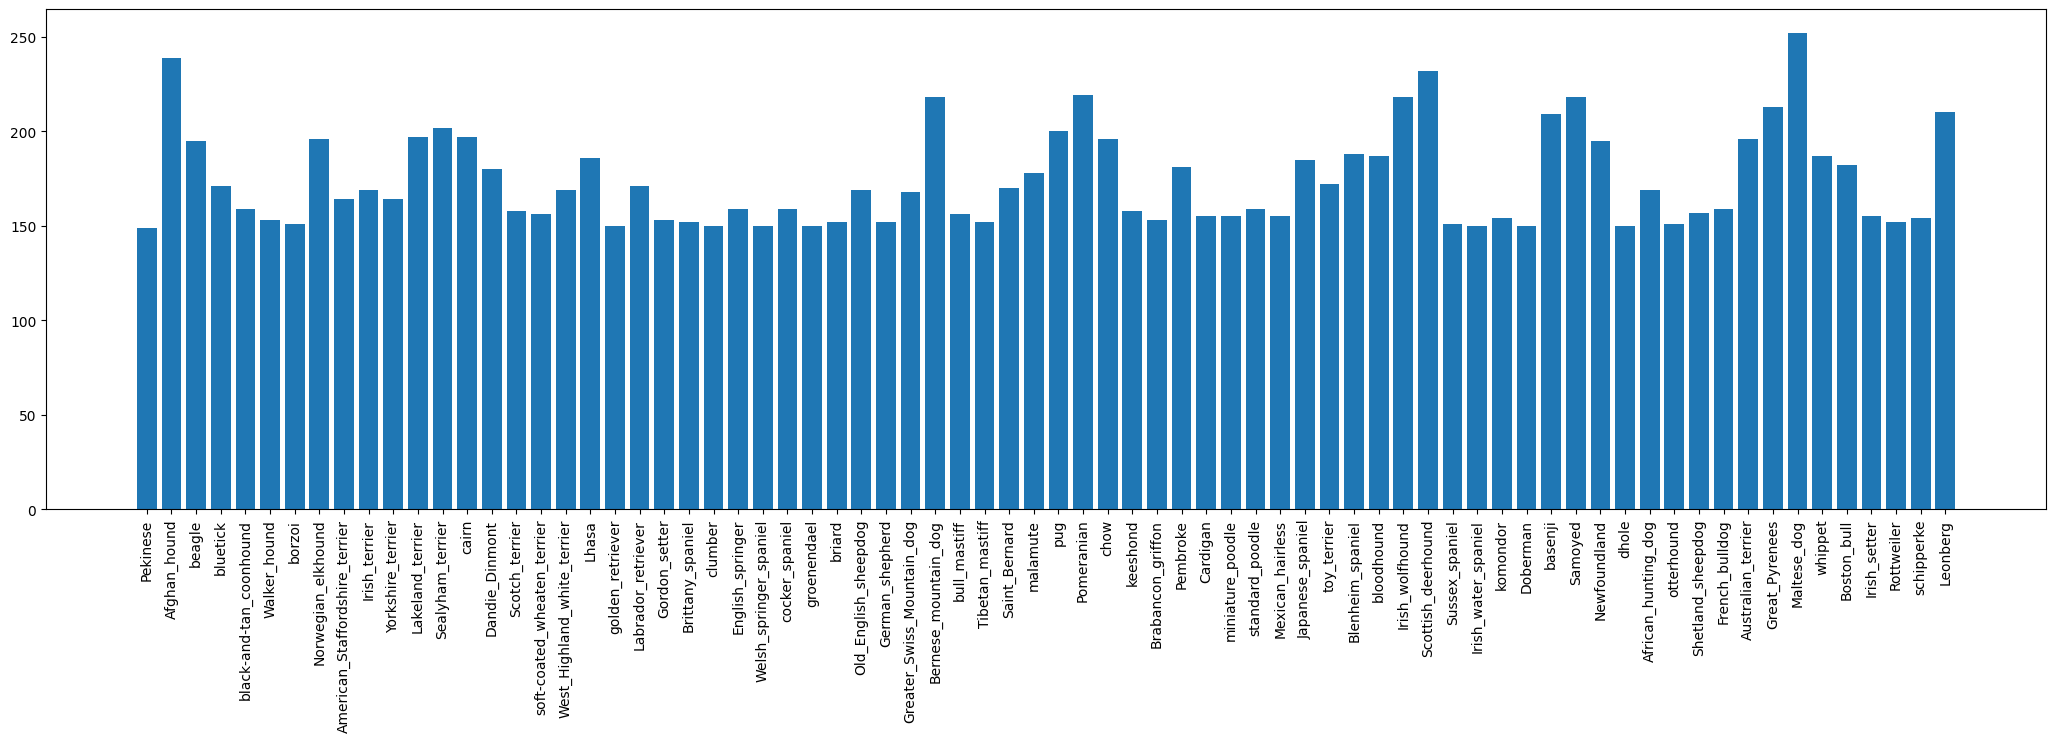

In [ ]:
targets = [len([f for f in glob.glob(f"dog-dataset/dog-images/{c}/**.jpg")]) for c in classes]

fig = plt.figure(figsize=(20, 5))
ax = fig.add_axes([0,0,1,1])
ax.bar(classes,targets)
plt.xticks(rotation='vertical')
plt.show()

---

# Data Preprocessing

This section loads the training, validation, and test data into `tf.data.Dataset` objects.

In other exercises we used `tf.keras.utils.Sequence` to batch images, but that API is still evolving and requires deeper knowledge of the TensorFlow data model to squeeze out good performance.

For this project, utility functions are provided that let us focus on modeling rather than data plumbing.

In [ ]:
def read_image(image_path, label):
    """
      Cargamos una imagen usando su ruta (path), la convertimos en tensor y la normalizamos
    """
    contents = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(contents, channels=3)
    img = tf.cast(img, tf.float64)
    img /= 255.0
    return img, label

def resize_image(img, label, target_size):
    """
      Redimensionamos una imagen
    """
    resized_img = tf.image.resize(img, target_size)
    return resized_img, label

def get_dataset(image_paths, image_labels, target_size, batch_size, prep_func=None):
    """
      - Generamos un objeto tf.data.Dataset para optimizar el entrenamiento desde los
        paths de las imagenes
      - Aplicamos las funciones read_image y resize_image a las imagenes
      - Podemos usar una función prep_func si queremos hacer fine-tunning
    """
    dataset = tf.data.Dataset.from_tensor_slices((image_paths, image_labels))
    dataset = dataset.map(read_image)
    dataset = dataset.map(lambda x, y: resize_image(x, y, target_size))

    if prep_func != None:
        dataset = dataset.map(lambda x, y: (x*255.0, y))
        dataset = dataset.map(lambda x, y: (prep_func(x), y))
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(1)
    return dataset

The utility functions construct `tf.data.Dataset` objects — TensorFlow's optimized iterator for streaming images through the model. Usage pattern:

```python
# Define target image size and batch size
img_size = (224, 224, 3)
batch_size = 32

# Build the training dataset (optionally passing a preprocessing function)
train_dataset = get_dataset(images_train_paths, labels_train, img_size[0:-1], batch_size)

# Train the model
model.fit(train_dataset, epochs=10)
```

This is the pattern used throughout the rest of the notebook whenever we train a model.

Although CSVs already define the train/valid/test splits, we'll regenerate them manually as a sanity check and for reproducibility.

In [ ]:
num_to_label = {i: c for i, c in enumerate(classes)}
label_to_num = {c: i for i, c in enumerate(classes)}
image_paths = np.array([f for f in glob.glob("dog-dataset/dog-images/**/*.jpg", recursive=True)])
image_labels =  np.array([label_to_num[f.split('/')[-2]] for f in glob.glob("dog-dataset/dog-images/**/*.jpg", recursive=True)])

In [ ]:
shuffler = np.random.permutation(len(image_paths))
image_paths = image_paths[shuffler]
image_labels = image_labels[shuffler]

# Train/valid/test split
x_train_valid, x_test, y_train_valid, y_test = train_test_split(image_paths, image_labels, test_size=0.1, random_state=1234, stratify=image_labels)
x_train, x_valid, y_train, y_valid = train_test_split(x_train_valid, y_train_valid, test_size=0.2, random_state=5678, stratify=y_train_valid)

print("Train: ", x_train.shape)
print("Valid: ", x_valid.shape)
print("Test: ", x_test.shape)

del x_train_valid, y_train_valid

Train:  (9280,)
Valid:  (2321,)
Test:  (1290,)


Once the partitions are ready, we build the datasets using the provided helpers.

---

# Baseline Experiment

A small example to illustrate the training loop and evaluation — each of the models below follows the same pattern.

## Architecture and training configuration

Network:
* Input shape: `(100, 120, 3)`
* Fully-connected layer with 1 neuron and ReLU activation
* Softmax output layer

Training:
* Loss: `categorical_crossentropy`
* Optimizer: Adam
* Learning rate: 0.001
* Epochs: 2
* Batch size: 128

In [ ]:
# Cargamos datos con las funciones de generación de dataset
img_size = (100,120,3)
train_dataset = get_dataset(x_train, y_train, img_size[:-1], 128)
valid_dataset = get_dataset(x_valid, y_valid, img_size[:-1], 128)
test_dataset = get_dataset(x_test, y_test, img_size[:-1], 128)

In [ ]:
# Creamos nuestra red
model = tf.keras.Sequential([
  tf.keras.layers.Input(img_size),
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(1, activation="relu"),
  tf.keras.layers.Dense(len(classes), activation="softmax")
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 36000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        36,001 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 74)             │           148 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,149 (141.21 KB)

 Trainable params: 36,149 (141.21 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Configuramos entrenamiento
opt = tf.keras.optimizers.Adam(learning_rate=0.001)

model.compile(optimizer=opt,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
# Entrenamos
history = model.fit(train_dataset, epochs=2, validation_data=valid_dataset)

Epoch 1/2
73/73 ━━━━━━━━━━━━━━━━━━━━ 43s 554ms/step - accuracy: 0.0129 - loss: 4.3212 - val_accuracy: 0.0198 - val_loss: 4.3023
Epoch 2/2
73/73 ━━━━━━━━━━━━━━━━━━━━ 40s 543ms/step - accuracy: 0.0187 - loss: 4.3020 - val_accuracy: 0.0198 - val_loss: 4.3009


In [ ]:
# Evaluamos con el conjunto de test
model.evaluate(test_dataset)

11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 378ms/step - accuracy: 0.0207 - loss: 4.3010


[4.300784111022949, 0.01937984488904476]

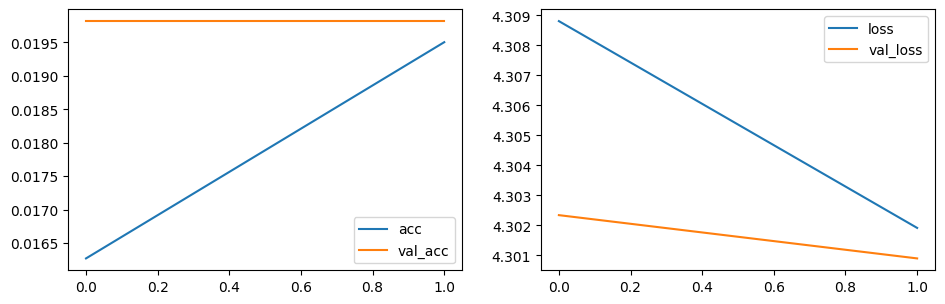

In [ ]:
# Visualizamos la evolución de los epochs
fig=plt.figure(figsize=(60, 40))

# error
fig.add_subplot(10, 10, 2)
plt.plot(history.history['loss'], label='loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()

# precision
fig.add_subplot(10, 10, 1)
plt.plot(history.history['accuracy'], label='acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()

plt.show()

11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 341ms/step


<Axes: >

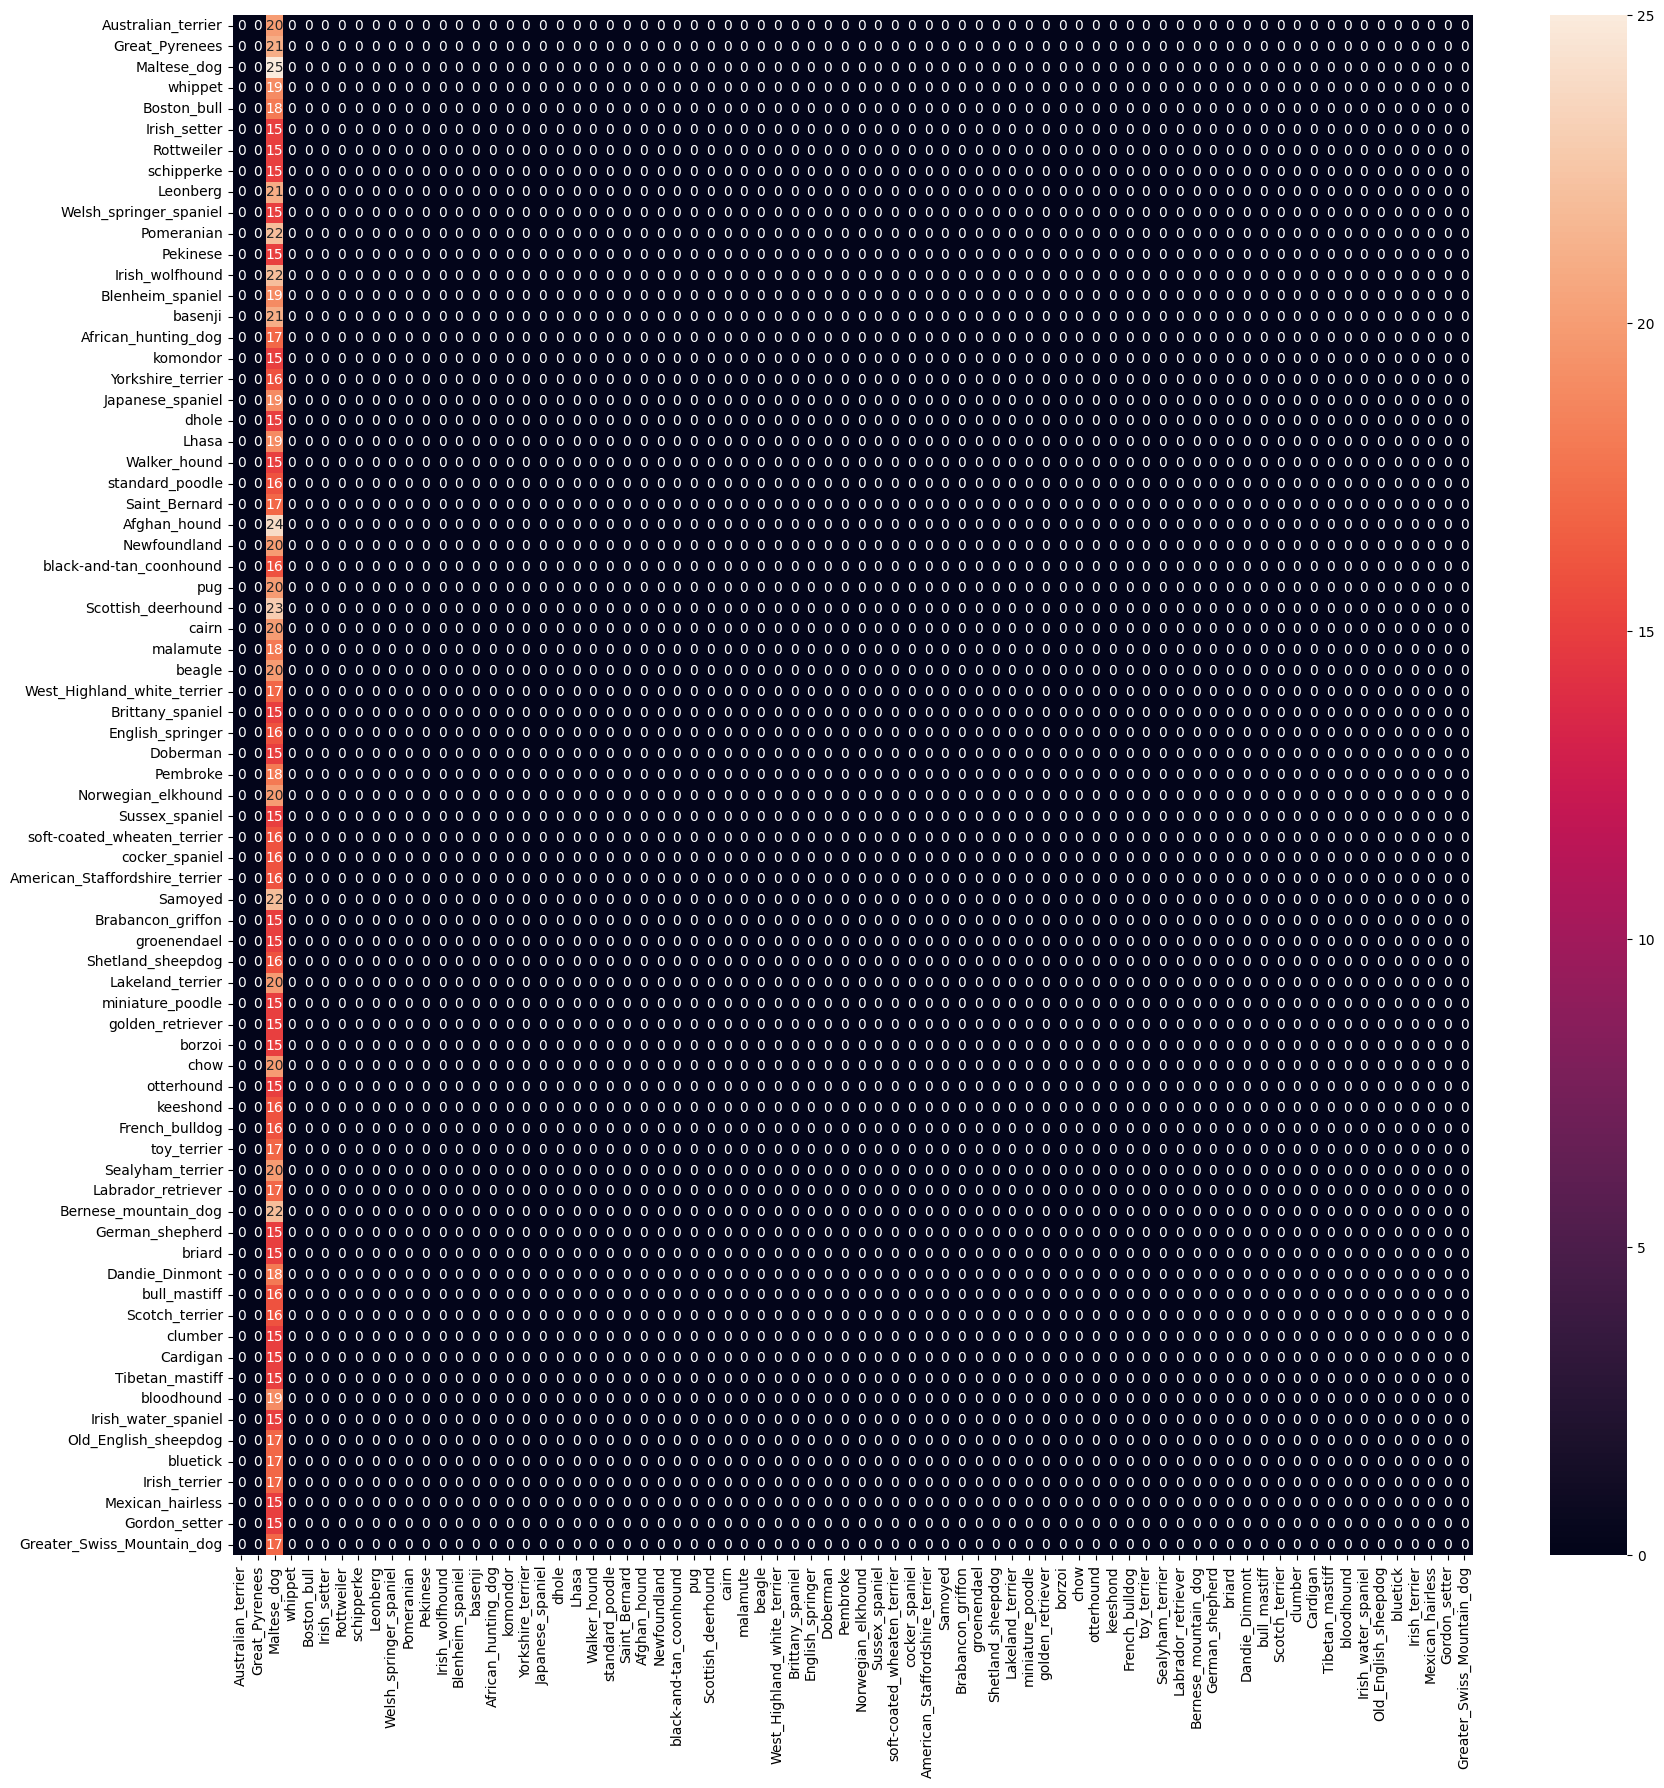

In [ ]:
# Visualizamos la matriz de confusion
predictions = model.predict(test_dataset)
y_pred = np.argmax(predictions, axis=1)
y_true= y_test
confusion_matrix = metrics.confusion_matrix(y_true=y_true, y_pred=y_pred)

df_cm=pd.DataFrame(confusion_matrix, index = [i for  i in classes], columns = [i for i in classes])
plt.figure(figsize = (20,20))
sns.heatmap(df_cm, annot=True)

---

# Model 1: CNN from Scratch

Train a VGG16-inspired convolutional network from random initialization and evaluate.

## Architecture and training configuration

Network:
* Input shape: `(100, 120, 3)`
* Convolutional layer, 32 kernels of size 5×5, ReLU
* Max-pooling with stride 2
* Convolutional layer, 64 kernels of size 5×5, ReLU
* Max-pooling with stride 2
* Fully-connected layer, 1024 neurons, ReLU
* Softmax output layer

Training:
* Loss: `categorical_crossentropy`
* Optimizer: Adam
* Learning rate: 0.001
* Epochs: 10
* Batch size: 128

In [ ]:
# Cargamos datos con las funciones de generación de dataset
img_size = (100,120,3)
train_dataset = get_dataset(x_train, y_train, img_size[:-1], 128)
valid_dataset = get_dataset(x_valid, y_valid, img_size[:-1], 128)
test_dataset = get_dataset(x_test, y_test, img_size[:-1], 128)

In [ ]:
#   - Crear la red
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(100, 120, 3)),

    tf.keras.layers.Conv2D(32, (5, 5), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    tf.keras.layers.Conv2D(64, (5, 5), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1024, activation='relu'),
    tf.keras.layers.Dense(len(classes), activation='softmax')
])

model.compile(
    loss='sparse_categorical_crossentropy',  # usa categorical_crossentropy si tus etiquetas están en one-hot
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=['accuracy']
)

model.summary()

#   - Entrena la red
history = model.fit(
    train_dataset,
    validation_data=valid_dataset,
    epochs=10
)



Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 96, 116, 32)    │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 48, 58, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 44, 54, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 22, 27, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 38016)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1024)           │    38,929,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 74)             │        75,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,058,954 (149.00 MB)

 Trainable params: 39,058,954 (149.00 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 46s 587ms/step - accuracy: 0.0192 - loss: 4.4546 - val_accuracy: 0.0379 - val_loss: 4.1684
Epoch 2/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 43s 587ms/step - accuracy: 0.0575 - loss: 4.0881 - val_accuracy: 0.0478 - val_loss: 4.1144
Epoch 3/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 80s 556ms/step - accuracy: 0.1579 - loss: 3.5406 - val_accuracy: 0.0508 - val_loss: 4.4723
Epoch 4/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 43s 582ms/step - accuracy: 0.3700 - loss: 2.5602 - val_accuracy: 0.0595 - val_loss: 5.8018
Epoch 5/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 41s 566ms/step - accuracy: 0.6288 - loss: 1.4717 - val_accuracy: 0.0508 - val_loss: 7.9200
Epoch 6/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 41s 569ms/step - accuracy: 0.7755 - loss: 0.9046 - val_accuracy: 0.0526 - val_loss: 8.5219
Epoch 7/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 80s 540ms/step - accuracy: 0.8485 - loss: 0.6351 - val_accuracy: 0.0504 - val_loss: 9.5993
Epoch 8/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 42s 576ms/step - accuracy: 0.9037 - loss: 0.3866 - val_accu

11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 423ms/step - accuracy: 0.0589 - loss: 11.2707
Test Loss: 11.2369 - Test Accuracy: 0.0659


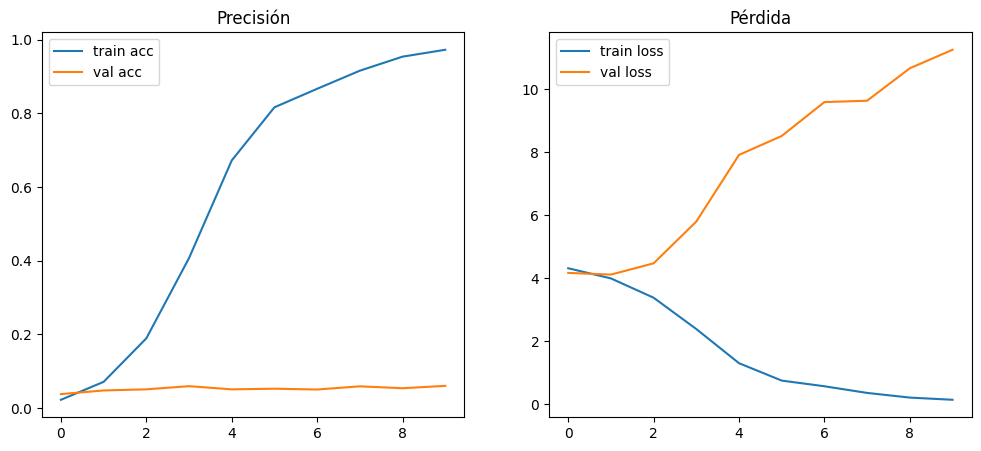

11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 460ms/step


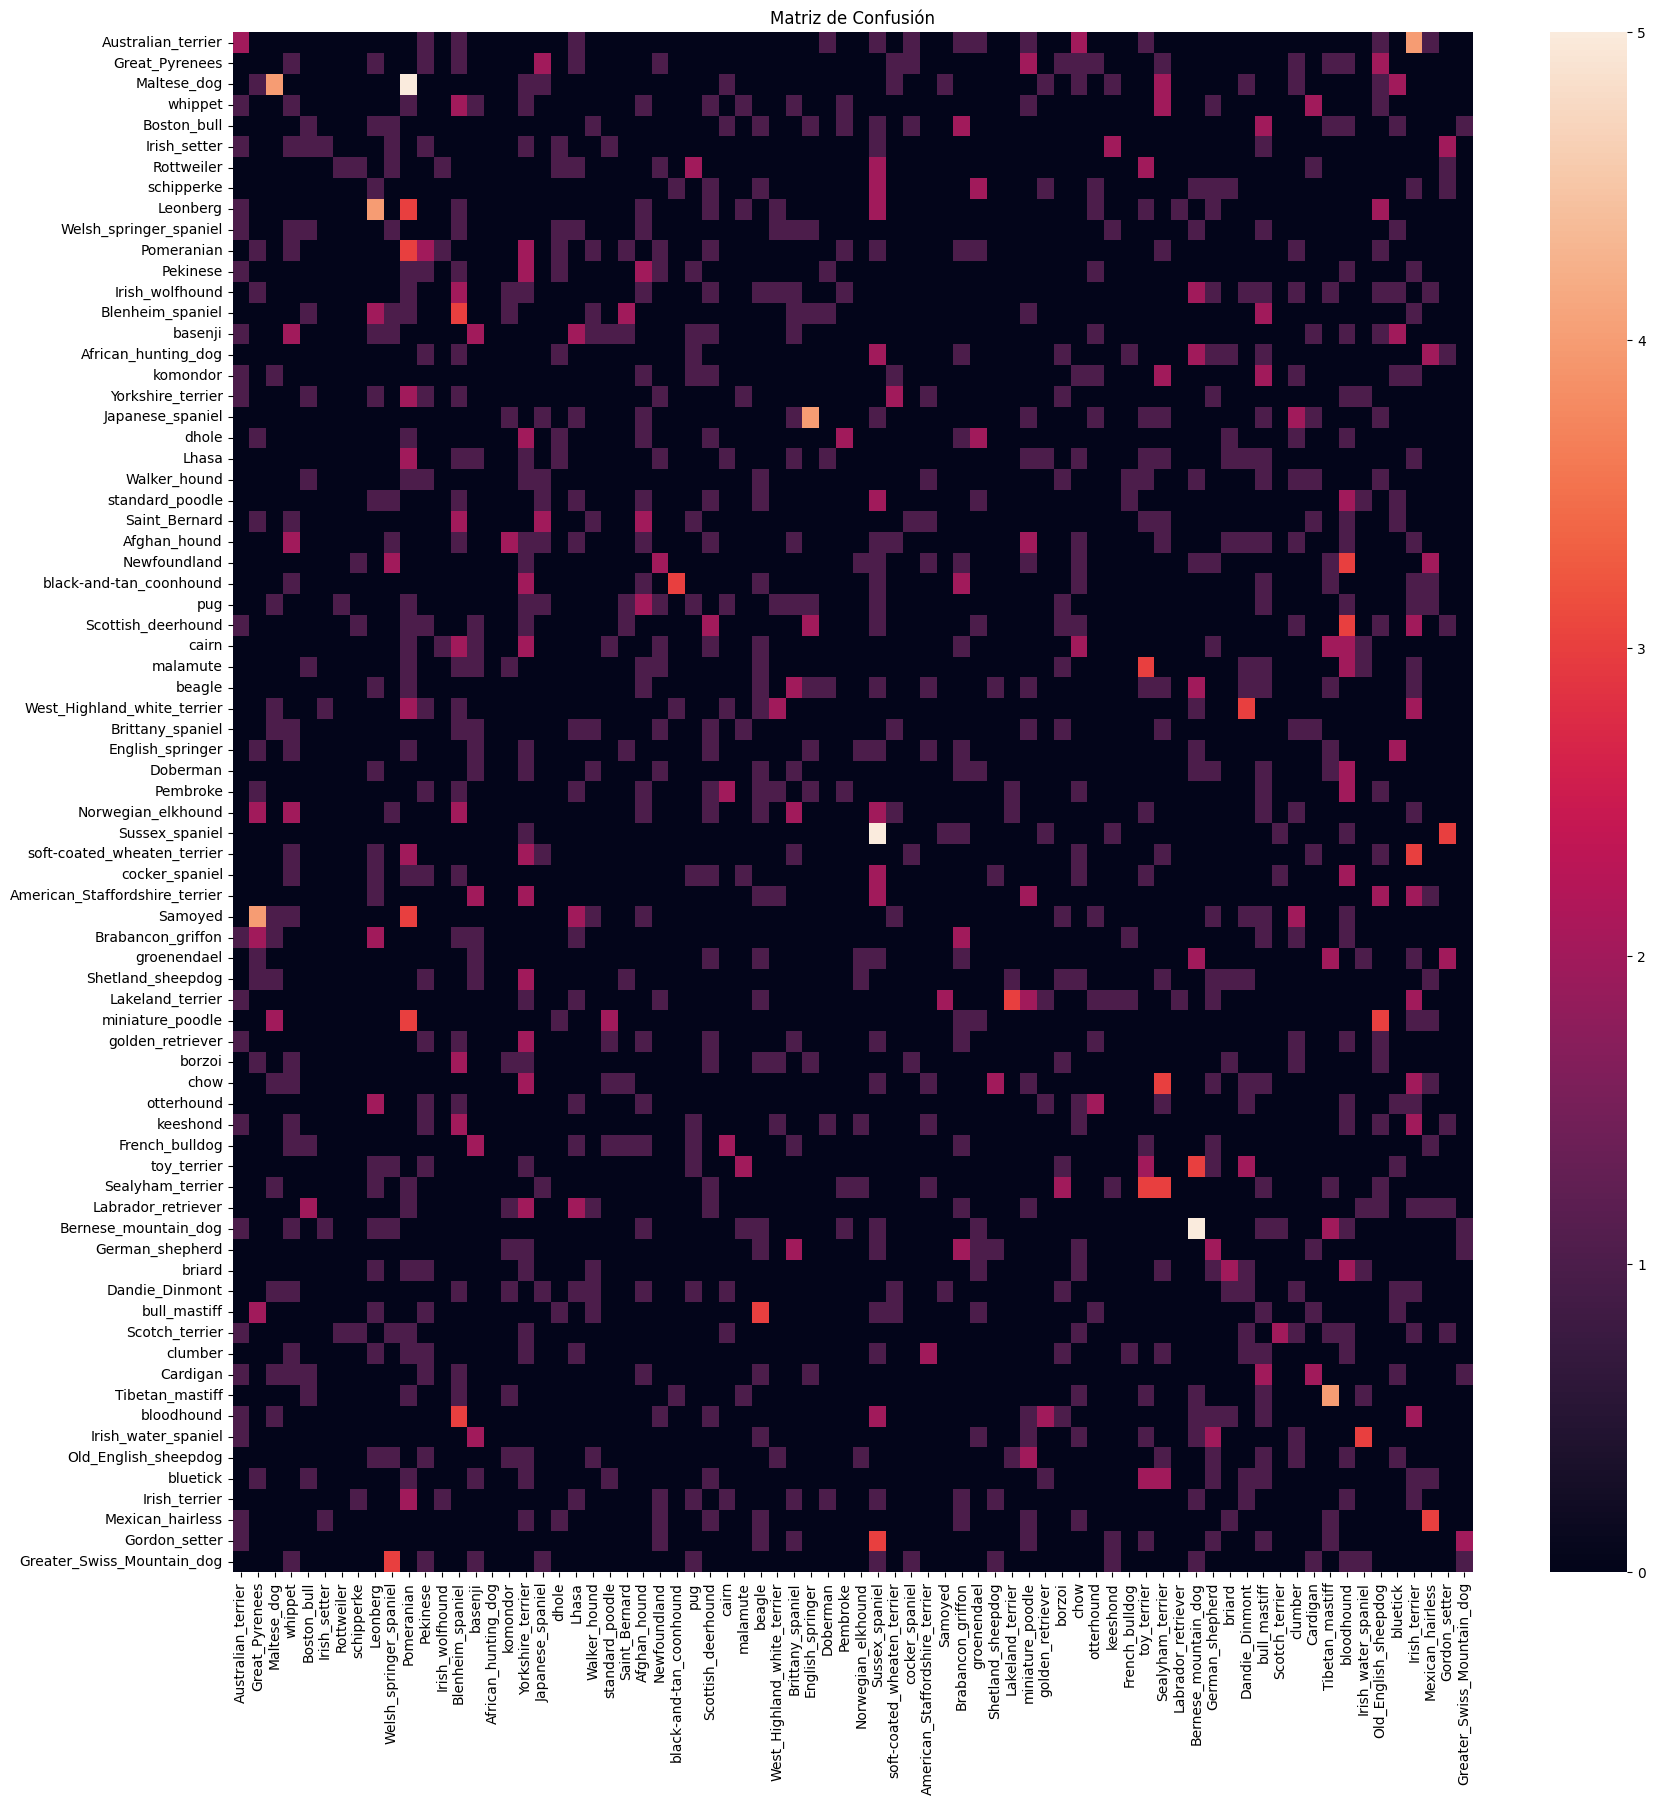

In [ ]:
#Evaluar la red
test_loss, test_acc = model.evaluate(test_dataset)
print(f"Test Loss: {test_loss:.4f} - Test Accuracy: {test_acc:.4f}")


plt.figure(figsize=(12, 5))


plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.title('Precisión')
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title('Pérdida')
plt.legend()

plt.show()


predictions = model.predict(test_dataset)
y_pred = np.argmax(predictions, axis=1)
y_true = y_test


conf_matrix = metrics.confusion_matrix(y_true, y_pred)


df_cm = pd.DataFrame(conf_matrix, index=classes, columns=classes)


plt.figure(figsize=(20, 20))
sns.heatmap(df_cm, annot=False, fmt='d', cmap='rocket')
plt.title("Matriz de Confusión")
plt.show()


### Analysis

The model is severely overfit. Training accuracy approaches 100% while validation accuracy plateaus around 5–7% — barely above chance for a 74-class problem. The loss curves confirm this: training loss drops to nearly zero while validation loss grows steadily after the first few epochs.

The confusion matrix is diffuse with no concentration on the diagonal — the model has memorized the training set without learning useful representations.

The network has too much capacity relative to the dataset size and complexity. To improve we need regularization, data augmentation, or — much more effective — transfer learning from a pre-trained model.

---

# Model 2: Hyperparameter Tuning

Improve the previous CNN by adding `Dropout` layers and tweaking the architecture.

## Architecture and training configuration

Network:
* Input shape: `(100, 120, 3)`
* Convolutional layer, 32 kernels of size 5×5, ReLU
* Max-pooling with stride 2
* **Dropout layer with rate 0.5**
* Convolutional layer, 64 kernels of size 5×5, ReLU
* Max-pooling with stride 2
* Convolutional layer, 64 kernels of size 5×5, ReLU
* Max-pooling with stride 2
* **Dropout layer with rate 0.5**
* Fully-connected layer, 1024 neurons, ReLU
* **Dropout layer with rate 0.2**
* Softmax output layer

Training:
* Loss: `categorical_crossentropy`
* Optimizer: Adam
* Learning rate: 0.001
* Epochs: 10
* Batch size: 128

In [ ]:
# Cargamos datos con las funciones de generación de dataset
img_size = (100,120,3)
train_dataset = get_dataset(x_train, y_train, img_size[:-1], 128)
valid_dataset = get_dataset(x_valid, y_valid, img_size[:-1], 128)
test_dataset = get_dataset(x_test, y_test, img_size[:-1], 128)

In [ ]:
#   - Crear la red
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(100, 120, 3)),

    tf.keras.layers.Conv2D(32, (5, 5), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Conv2D(64, (5, 5), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    tf.keras.layers.Conv2D(64, (5, 5), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1024, activation='relu'),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(len(classes), activation='softmax')
])

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=['accuracy']
)

model.summary()

#   - Entrena la red
history = model.fit(
    train_dataset,
    validation_data=valid_dataset,
    epochs=10
)



Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 96, 116, 32)    │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 48, 58, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 48, 58, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 44, 54, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 22, 27, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 18, 23, 64)     │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 9, 11, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 9, 11, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 6336)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1024)           │     6,489,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 74)             │        75,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,721,098 (25.64 MB)

 Trainable params: 6,721,098 (25.64 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 56s 690ms/step - accuracy: 0.0169 - loss: 4.3123 - val_accuracy: 0.0353 - val_loss: 4.2798
Epoch 2/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 44s 608ms/step - accuracy: 0.0334 - loss: 4.2029 - val_accuracy: 0.0487 - val_loss: 4.0986
Epoch 3/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 40s 542ms/step - accuracy: 0.0481 - loss: 4.0544 - val_accuracy: 0.0603 - val_loss: 3.9910
Epoch 4/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 43s 585ms/step - accuracy: 0.0722 - loss: 3.9192 - val_accuracy: 0.0776 - val_loss: 3.8723
Epoch 5/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 81s 574ms/step - accuracy: 0.0886 - loss: 3.7784 - val_accuracy: 0.0900 - val_loss: 3.8051
Epoch 6/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 83s 590ms/step - accuracy: 0.1145 - loss: 3.6319 - val_accuracy: 0.1056 - val_loss: 3.7653
Epoch 7/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 41s 564ms/step - accuracy: 0.1461 - loss: 3.4910 - val_accuracy: 0.0892 - val_loss: 3.8251
Epoch 8/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 84s 587ms/step - accuracy: 0.1596 - loss: 3.4236 - val_accu

11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 516ms/step - accuracy: 0.0900 - loss: 3.9778
Test Loss: 3.9940 - Test Accuracy: 0.0969


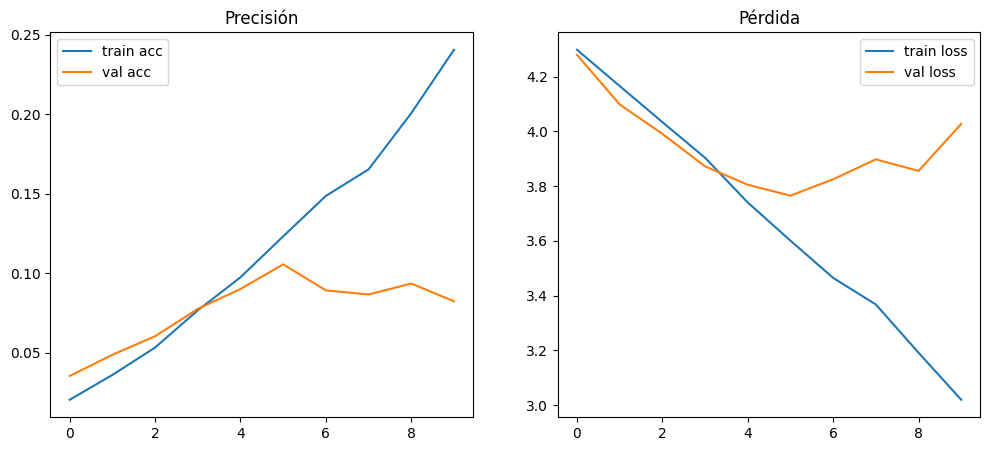

11/11 ━━━━━━━━━━━━━━━━━━━━ 4s 329ms/step


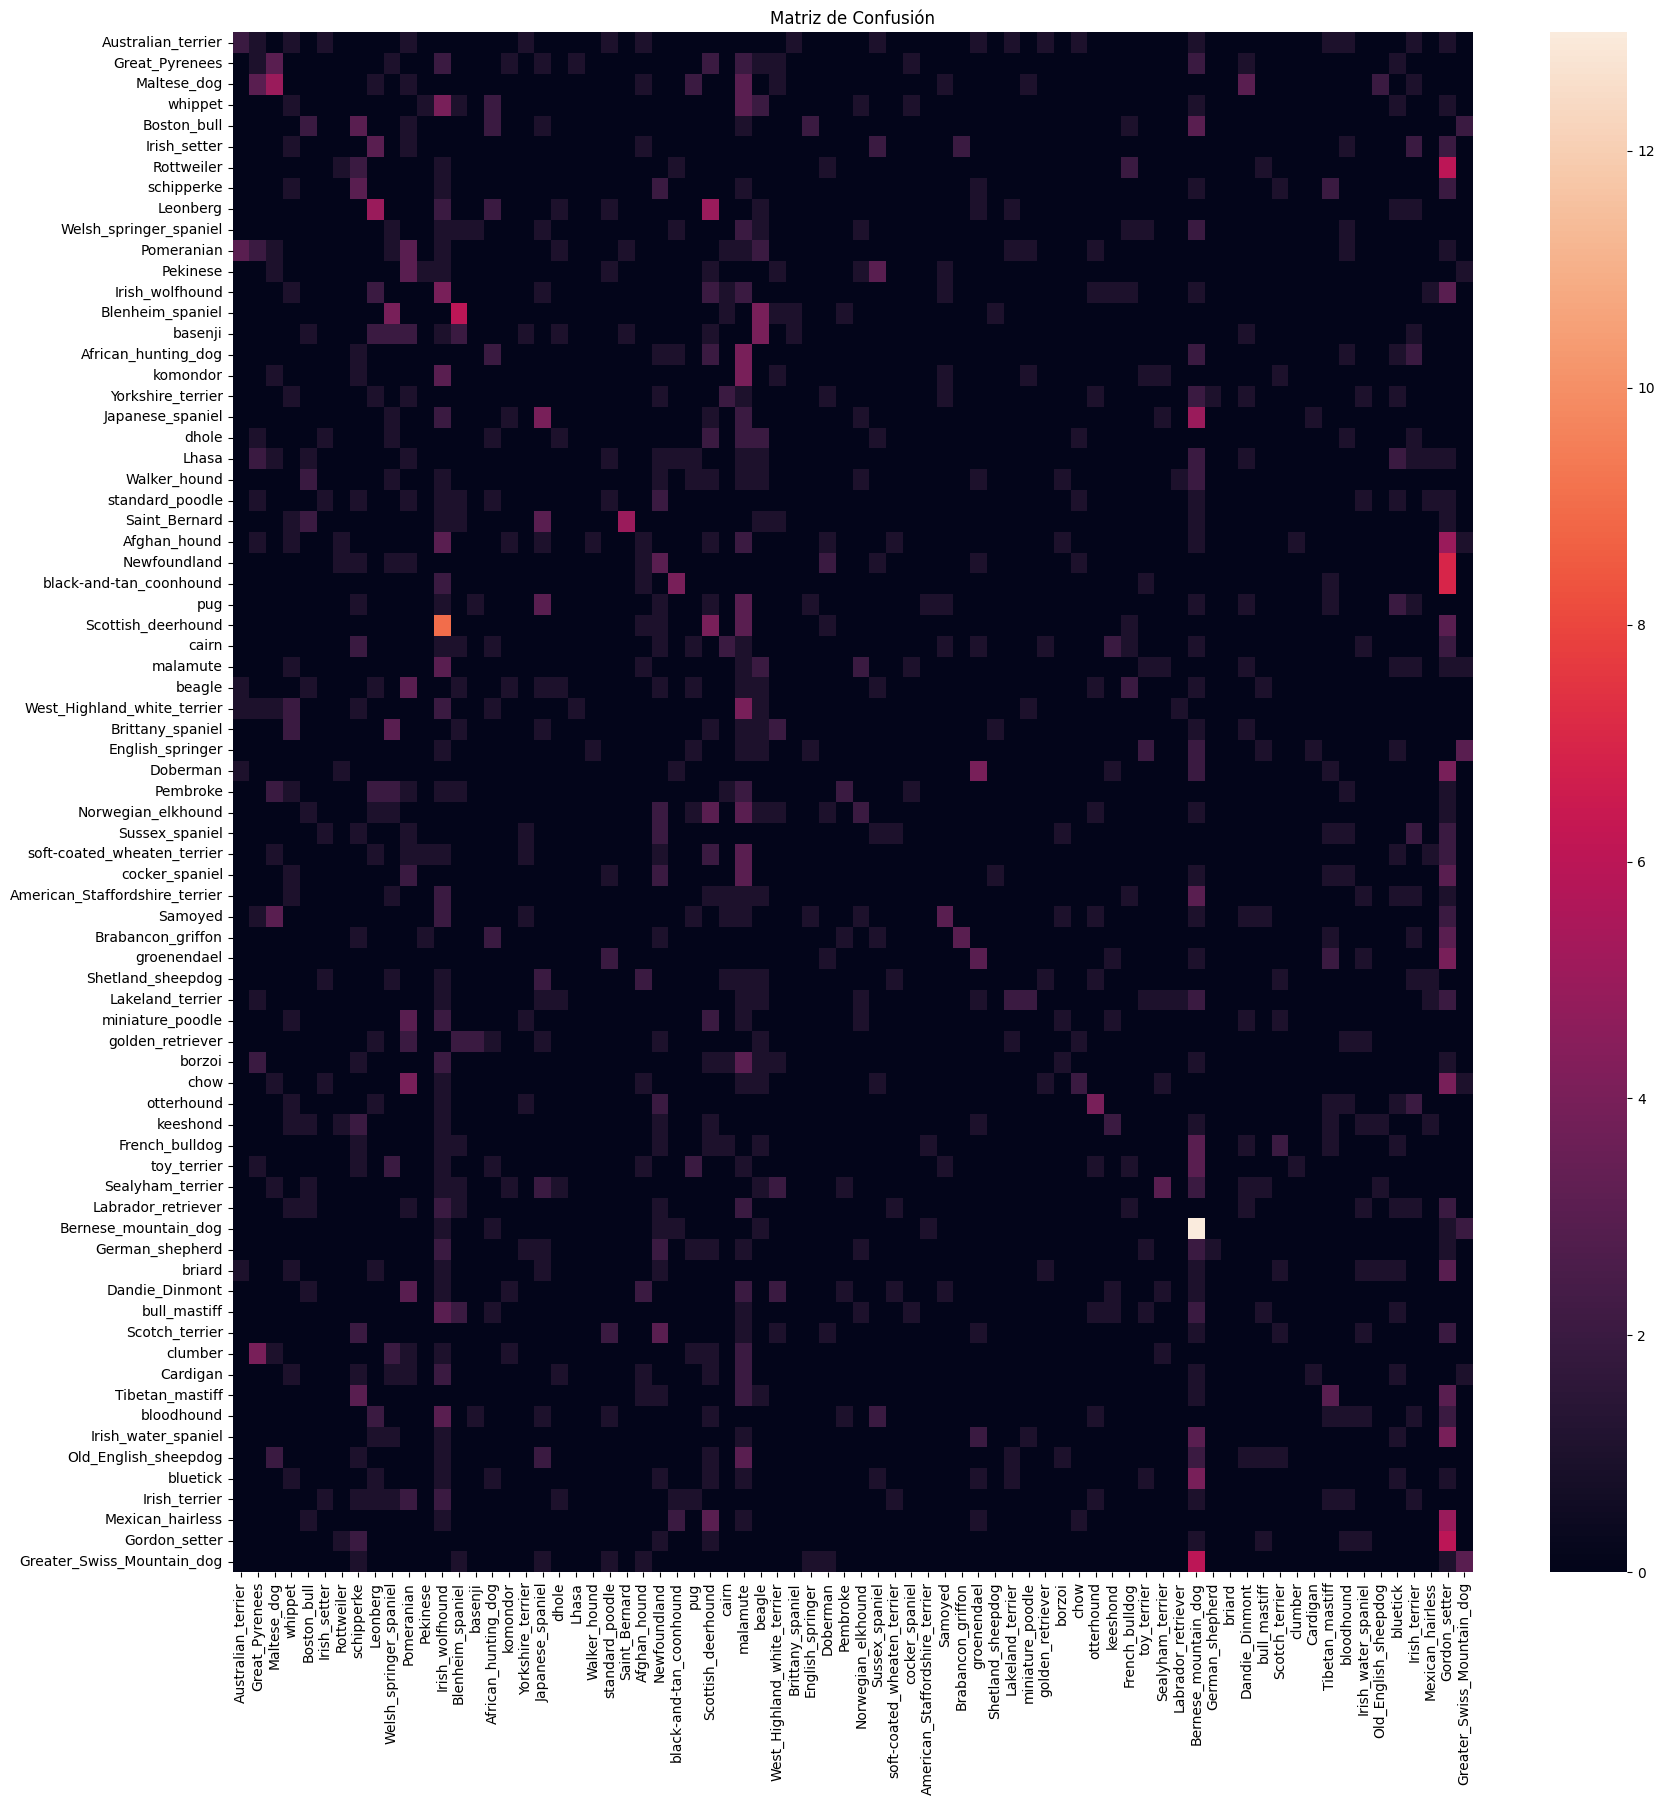

In [ ]:
#Evaluar la Red

test_loss, test_acc = model.evaluate(test_dataset)
print(f"Test Loss: {test_loss:.4f} - Test Accuracy: {test_acc:.4f}")


plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.title('Precisión')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title('Pérdida')
plt.legend()

plt.show()

predictions = model.predict(test_dataset)
y_pred = np.argmax(predictions, axis=1)
y_true = y_test

cm = metrics.confusion_matrix(y_true, y_pred)
df_cm = pd.DataFrame(cm, index=classes, columns=classes)

plt.figure(figsize=(20, 20))
sns.heatmap(df_cm, annot=False, fmt='d', cmap='rocket')
plt.title("Matriz de Confusión")
plt.show()


### Analysis

The Dropout-augmented model shows more controlled training dynamics: training accuracy climbs steadily while validation accuracy reaches ~11% — a meaningful improvement over the baseline. Overfitting is still present (the gap between train and validation widens after epoch 5), but the loss curves are closer together, indicating better generalization thanks to regularization.

The confusion matrix shows the beginning of a diagonal pattern — a handful of classes are being learned correctly. But most of the matrix remains diffuse, meaning the model still struggles with most breeds.

Progress, but not enough. Data augmentation or transfer learning will be needed to make a meaningful leap.

---

# Model 3: Pre-trained Model (Fine-tuning)

Apply transfer learning with InceptionV3 — a well-established pre-trained architecture with strong fine-tuning performance.

## Inception

Architecture:
* Input shape: `(299, 299, 3)`
* Load with `include_top=False` and `pooling='avg'`
* Dropout layer with rate 0.5
* Softmax output layer

Training:
* Loss: `categorical_crossentropy`
* Optimizer: Adam
* Epochs: 10
* Batch size: 128

In [ ]:
# Cargamos datos con las funciones de generación de dataset
# esta vez usams la fucnion de preprocesamiento de inception
img_size = (299,299,3)
batch_size = 128
epochs = 10

train_dataset = get_dataset(x_train, y_train, img_size[0:-1], batch_size,
                            tf.keras.applications.inception_v3.preprocess_input)

valid_dataset = get_dataset(x_valid, y_valid, img_size[0:-1], batch_size,
                            tf.keras.applications.inception_v3.preprocess_input)

test_dataset = get_dataset(x_test, y_test, img_size[0:-1], batch_size,
                           tf.keras.applications.inception_v3.preprocess_input)

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)       │ (None, 2048)           │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 74)             │       151,626 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,954,410 (83.75 MB)

 Trainable params: 151,626 (592.29 KB)

 Non-trainable params: 21,802,784 (83.17 MB)

Epoch 1/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 2250s 30s/step - accuracy: 0.4691 - loss: 2.7264 - val_accuracy: 0.9517 - val_loss: 0.3076
Epoch 2/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 56s 728ms/step - accuracy: 0.9455 - loss: 0.2904 - val_accuracy: 0.9573 - val_loss: 0.1915
Epoch 3/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 64s 875ms/step - accuracy: 0.9543 - loss: 0.1886 - val_accuracy: 0.9561 - val_loss: 0.1657
Epoch 4/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 71s 725ms/step - accuracy: 0.9592 - loss: 0.1508 - val_accuracy: 0.9578 - val_loss: 0.1534
Epoch 5/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 82s 727ms/step - accuracy: 0.9649 - loss: 0.1290 - val_accuracy: 0.9578 - val_loss: 0.1497
Epoch 6/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 53s 721ms/step - accuracy: 0.9693 - loss: 0.1109 - val_accuracy: 0.9573 - val_loss: 0.1451
Epoch 7/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 92s 857ms/step - accuracy: 0.9719 - loss: 0.0998 - val_accuracy: 0.9578 - val_loss: 0.1440
Epoch 8/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 85s 905ms/step - accuracy: 0.9766 - loss: 0.0895 - val_accu

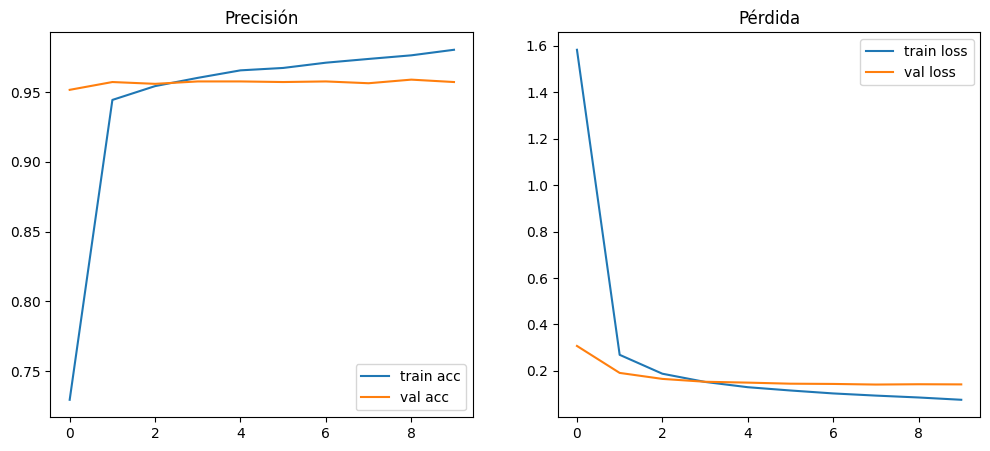

11/11 ━━━━━━━━━━━━━━━━━━━━ 19s 1s/step


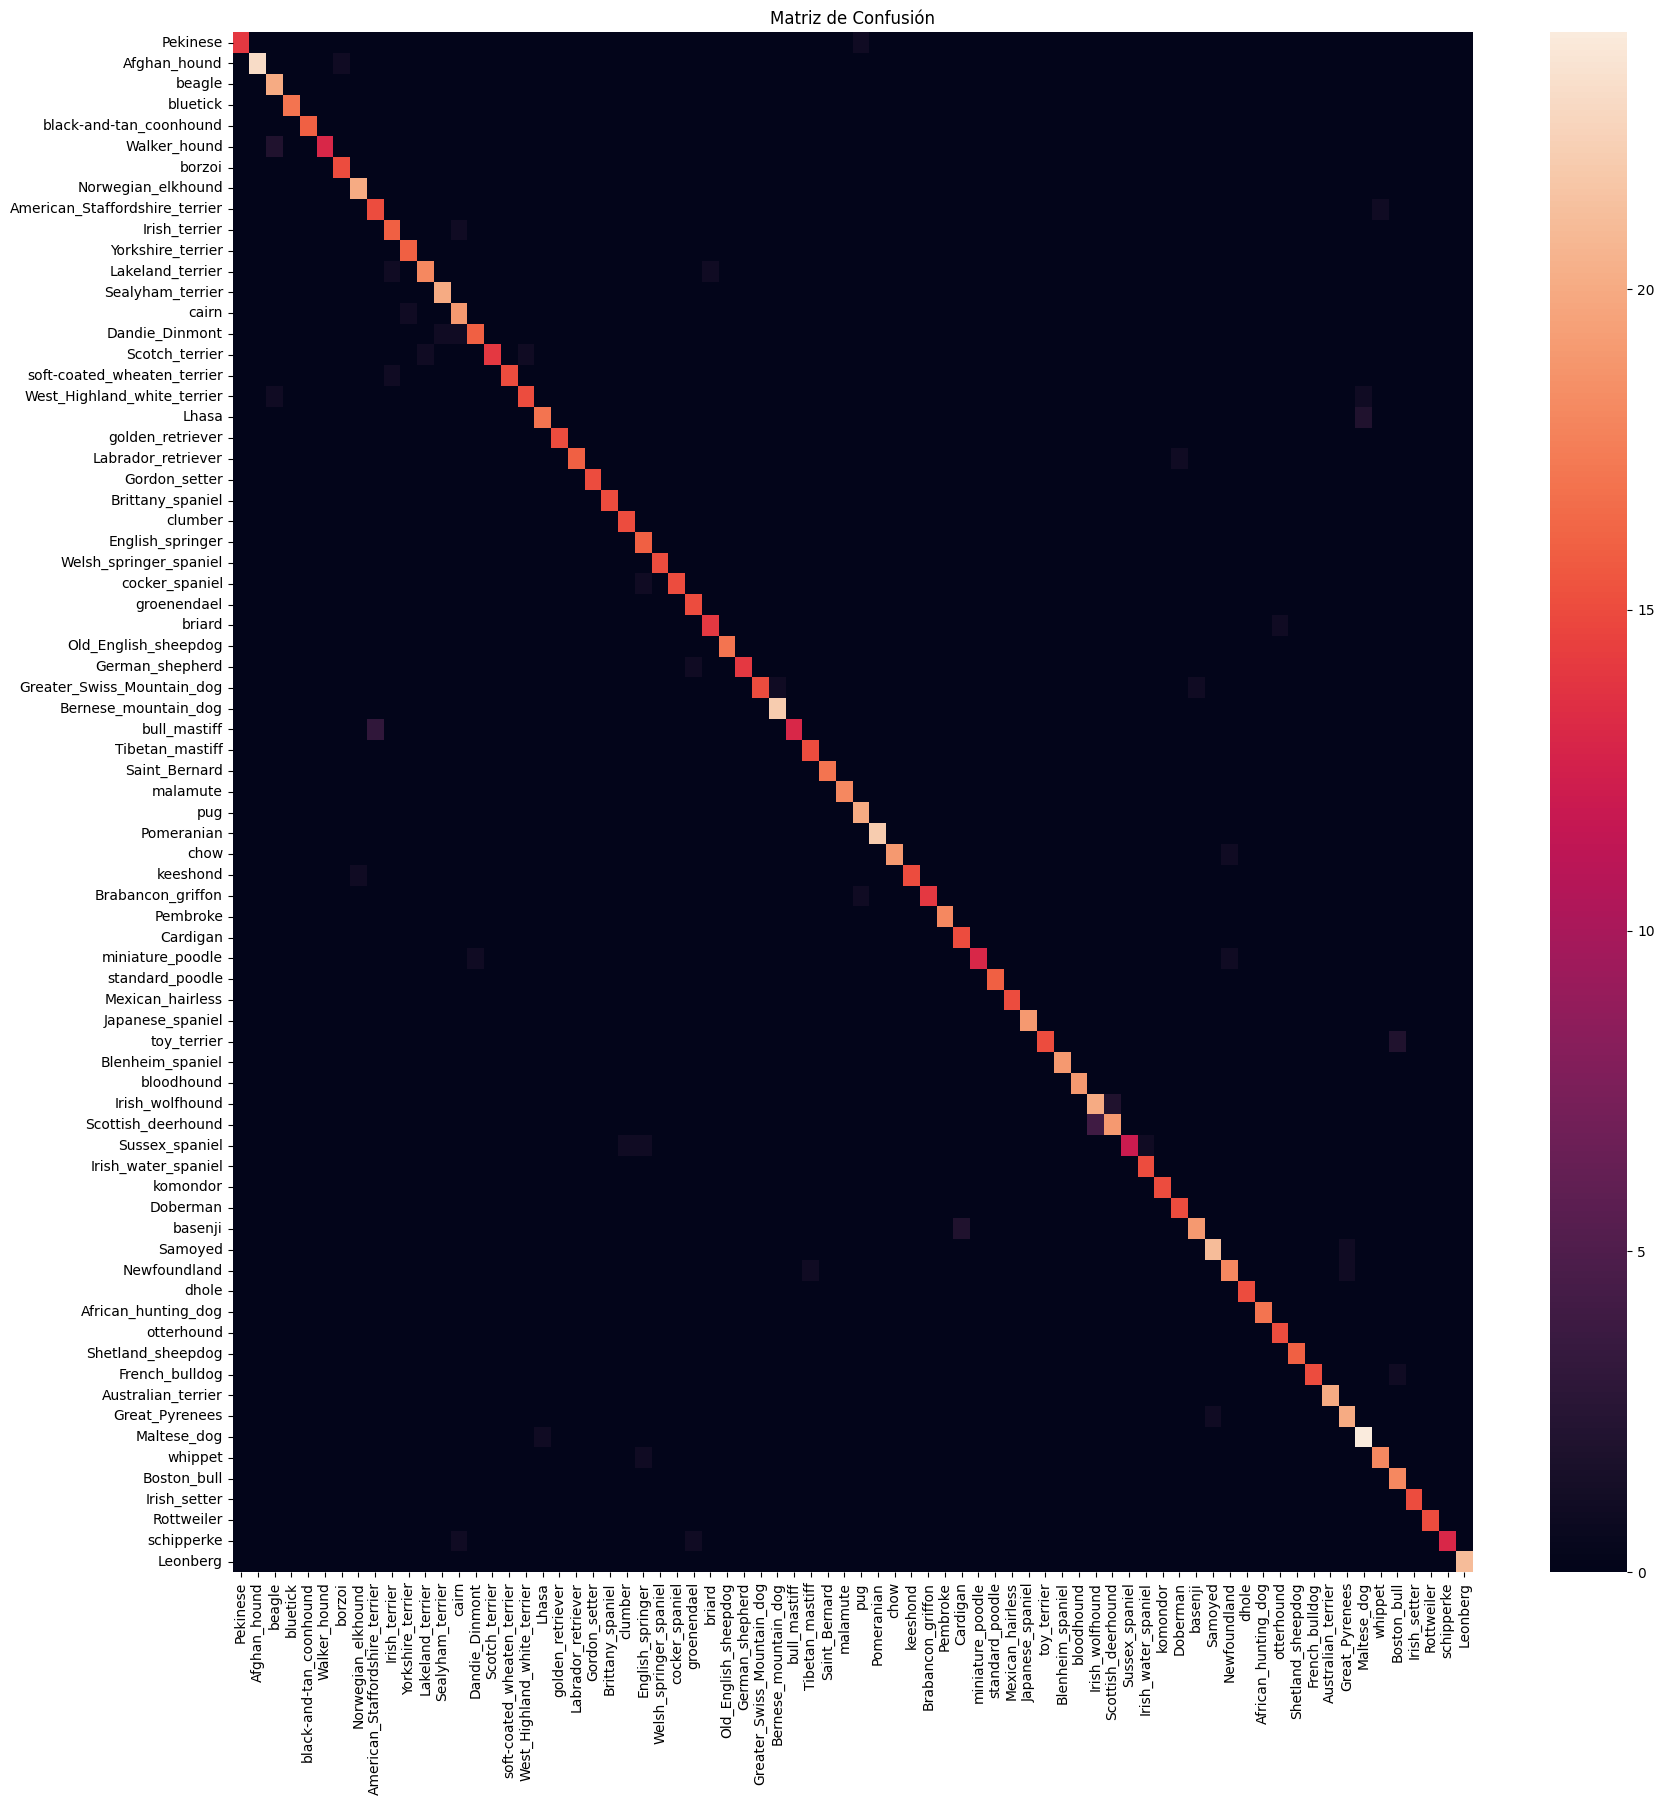

In [ ]:

#   - Crear la red
base_model = tf.keras.applications.InceptionV3(
    input_shape=(299, 299, 3),
    include_top=False,
    weights='imagenet',
    pooling='avg'
)

base_model.trainable = False

model = tf.keras.Sequential([
    base_model,
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(len(classes), activation='softmax')
])

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(),
    metrics=['accuracy']
)

model.summary()

#   - Entrena la red
history = model.fit(
    train_dataset,
    validation_data=valid_dataset,
    epochs=10
)

# Evaluación en test
test_loss, test_acc = model.evaluate(test_dataset)
print(f"Test Loss: {test_loss:.4f} - Test Accuracy: {test_acc:.4f}")

# Curvas de entrenamiento
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train acc')
plt.plot(history.history['val_accuracy'], label='val acc')
plt.title('Precisión')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title('Pérdida')
plt.legend()

plt.show()

# Matriz de confusión
predictions = model.predict(test_dataset)
y_pred = np.argmax(predictions, axis=1)
y_true = y_test  # Asumiendo que y_test sigue definido

cm = metrics.confusion_matrix(y_true, y_pred)
df_cm = pd.DataFrame(cm, index=classes, columns=classes)

plt.figure(figsize=(20, 20))
sns.heatmap(df_cm, annot=False, fmt='d', cmap='rocket')
plt.title("Matriz de Confusión")
plt.show()

### Analysis

InceptionV3 with fine-tuning delivers excellent results. Training accuracy reaches ~99% and validation accuracy stabilizes around 96% — strong generalization without overfitting. Loss curves stay low and balanced across training and validation, confirming stable learning.

The confusion matrix shows a sharp diagonal: the model classifies almost every breed correctly, with only a handful of scattered errors and no breed showing systematic failure.

The model has effectively learned to distinguish the 74 breeds. This is a solid baseline for deployment, and could be pushed further with a second fine-tuning pass that unfreezes deeper layers of the base network.

---

# Model 4: Data Augmentation

Apply stochastic data augmentation on top of the scratch CNN (Model 1) and test whether it improves performance. We use one or more of:

* Horizontal flip
* Vertical flip
* Contrast adjustment

## Architecture and training configuration

Network (same as Model 1):
* Input shape: `(100, 120, 3)`
* Convolutional layer, 32 kernels of size 5×5, ReLU
* Max-pooling with stride 2
* Convolutional layer, 64 kernels of size 5×5, ReLU
* Max-pooling with stride 2
* Fully-connected layer, 1024 neurons, ReLU
* Softmax output layer

Training:
* Loss: `categorical_crossentropy`
* Optimizer: Adam
* Learning rate: 0.001
* Epochs: 10
* Batch size: 128

In [ ]:
# Cargamos datos con las funciones de generación de dataset
img_size = (100,120,3)
batch_size = 128

train_dataset = get_dataset(x_train, y_train, img_size[:-1], batch_size)
valid_dataset = get_dataset(x_valid, y_valid, img_size[:-1], batch_size)
test_dataset = get_dataset(x_test, y_test, img_size[:-1], batch_size)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 96, 116, 32)    │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 48, 58, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 44, 54, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 22, 27, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 38016)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │    38,929,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 74)             │        75,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 39,058,954 (149.00 MB)

 Trainable params: 39,058,954 (149.00 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 4587s 63s/step - accuracy: 0.0188 - loss: 4.8174 - val_accuracy: 0.0332 - val_loss: 4.1905
Epoch 2/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 44s 602ms/step - accuracy: 0.0378 - loss: 4.1524 - val_accuracy: 0.0495 - val_loss: 4.0196
Epoch 3/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 48s 658ms/step - accuracy: 0.0696 - loss: 3.9266 - val_accuracy: 0.0625 - val_loss: 3.9092
Epoch 4/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 47s 648ms/step - accuracy: 0.0982 - loss: 3.7929 - val_accuracy: 0.0771 - val_loss: 3.8511
Epoch 5/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 47s 642ms/step - accuracy: 0.1165 - loss: 3.6689 - val_accuracy: 0.0844 - val_loss: 3.8302
Epoch 6/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 76s 568ms/step - accuracy: 0.1563 - loss: 3.5358 - val_accuracy: 0.0896 - val_loss: 3.8208
Epoch 7/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 85s 608ms/step - accuracy: 0.1860 - loss: 3.3342 - val_accuracy: 0.1000 - val_loss: 3.8648
Epoch 8/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 43s 585ms/step - accuracy: 0.2334 - loss: 3.1610 - val_accu

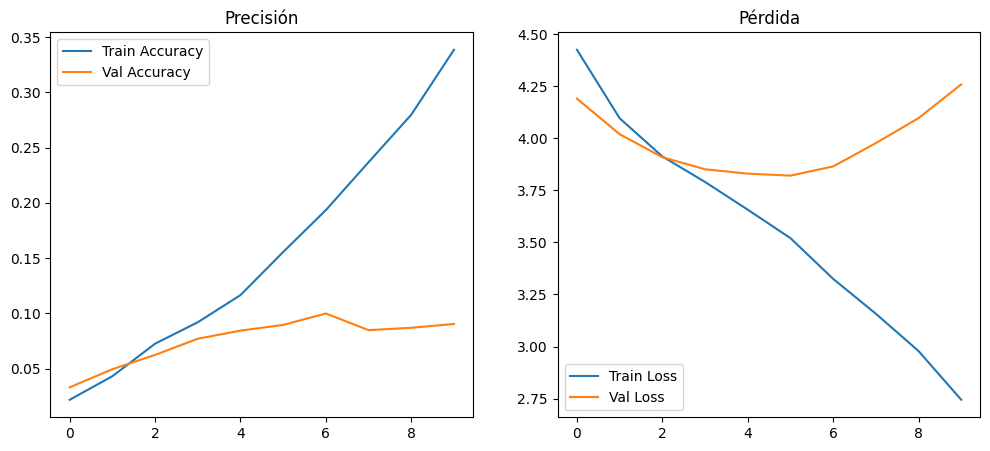

11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 368ms/step


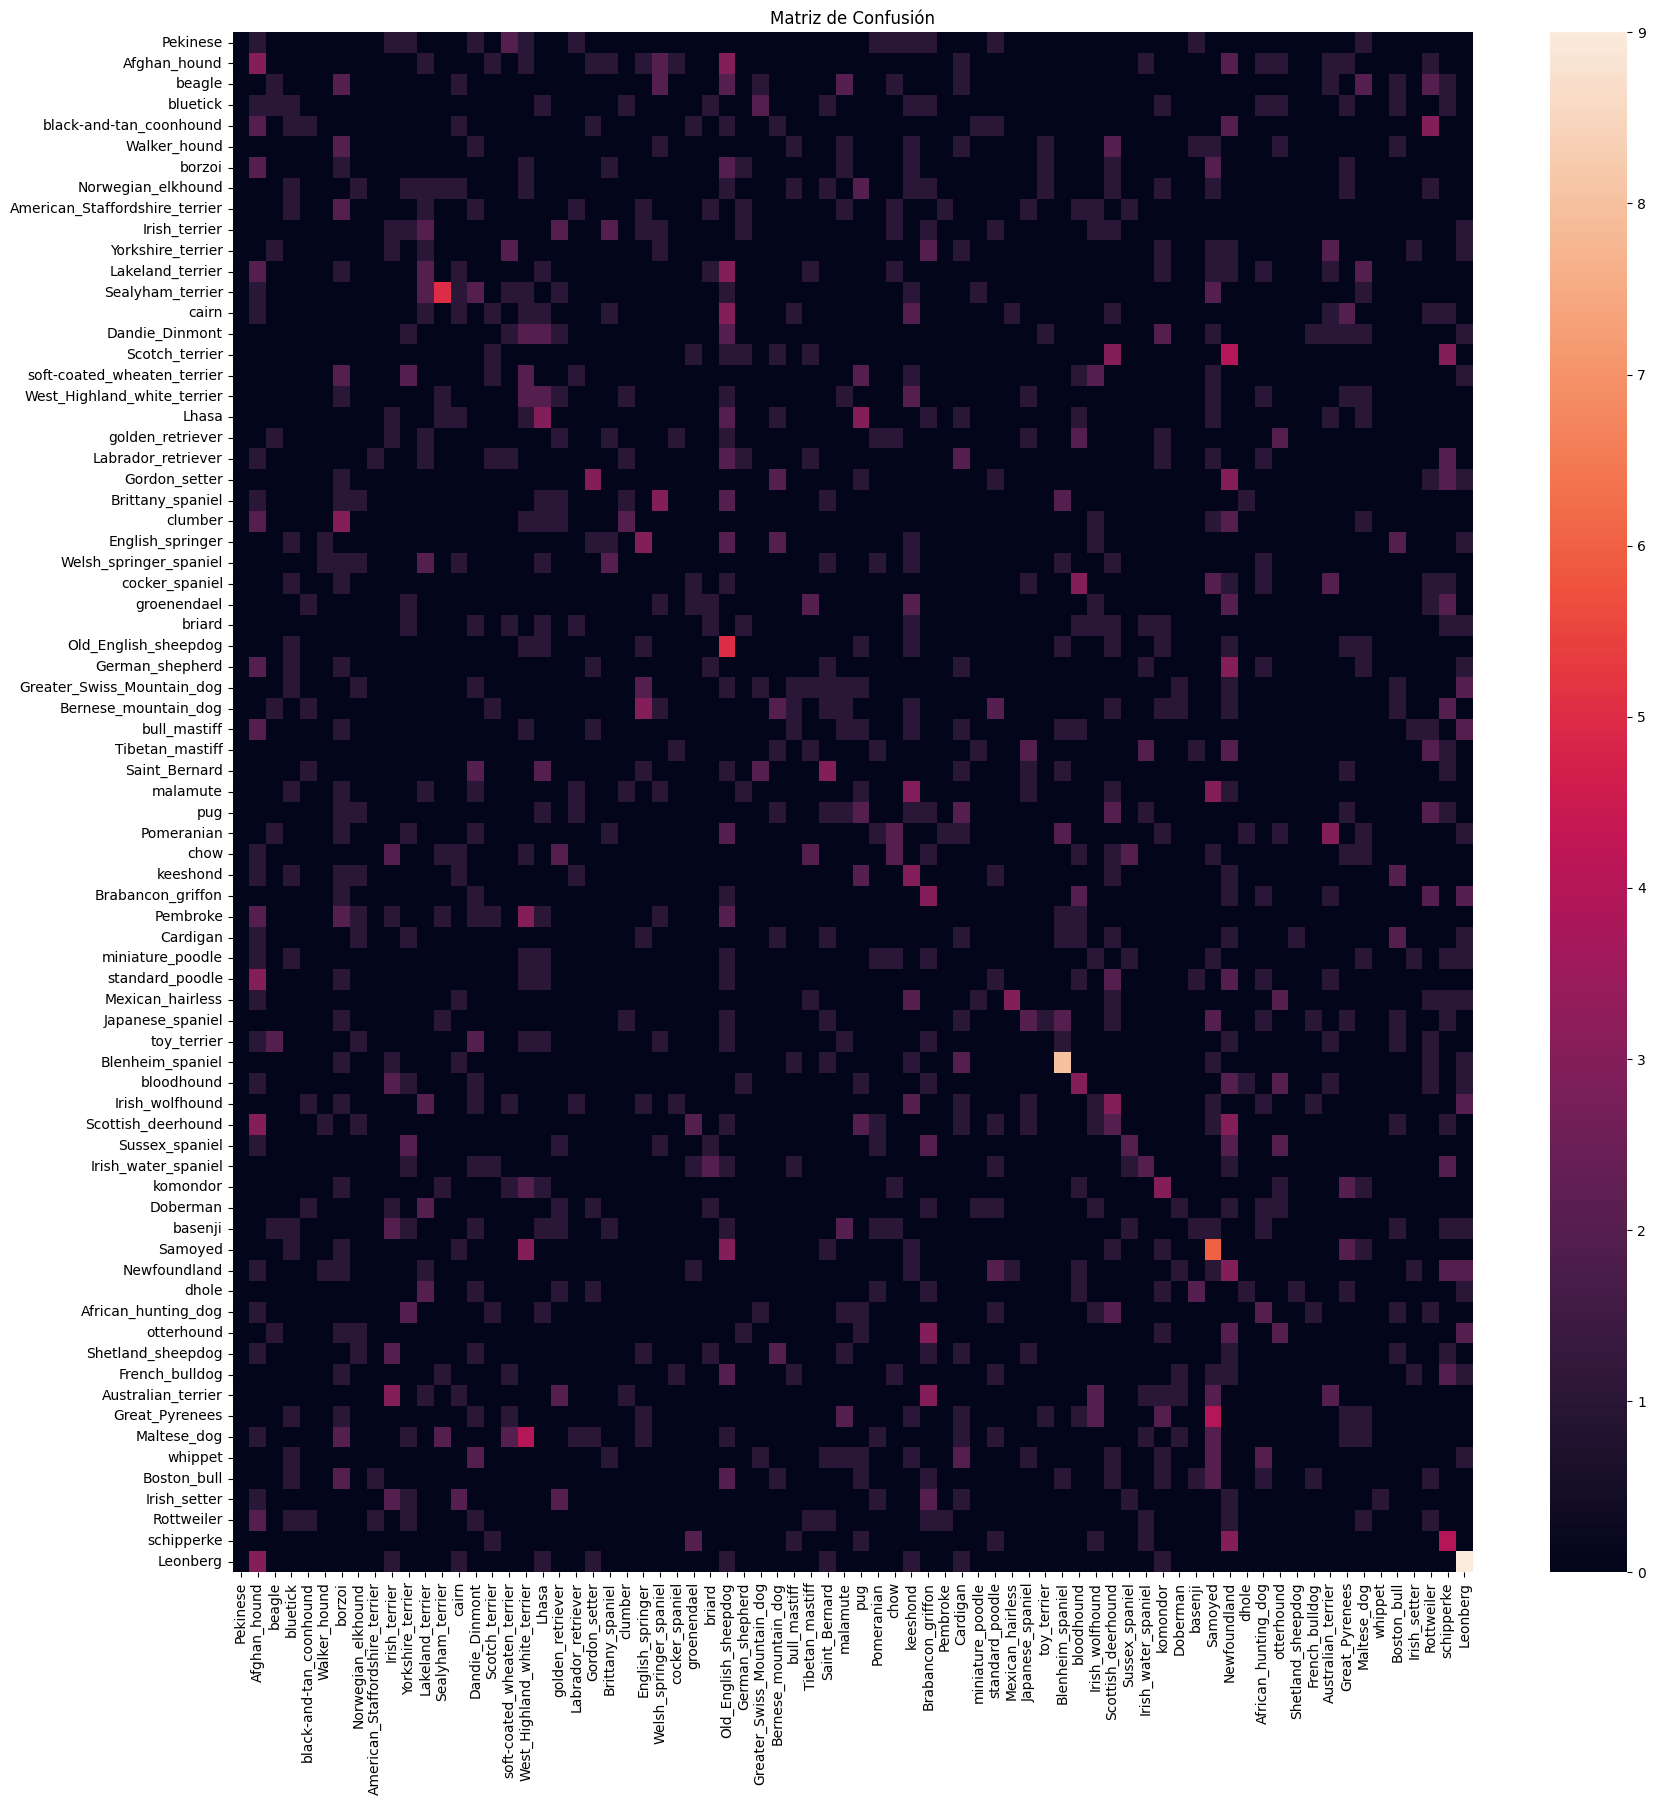

In [ ]:

def augment_image(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_contrast(img, lower=0.8, upper=1.2)
    return img, label


model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(100, 120, 3)),

    tf.keras.layers.Conv2D(32, (5, 5), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    tf.keras.layers.Conv2D(64, (5, 5), activation='relu'),
    tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1024, activation='relu'),

    tf.keras.layers.Dense(len(classes), activation='softmax')
])

model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    metrics=['accuracy']
)

model.summary()


img_size = (100, 120, 3)
batch_size = 128

train_dataset = get_dataset(x_train, y_train, img_size[:-1], batch_size)
train_dataset = train_dataset.map(augment_image).prefetch(1)

valid_dataset = get_dataset(x_valid, y_valid, img_size[:-1], batch_size)
test_dataset = get_dataset(x_test, y_test, img_size[:-1], batch_size)


history = model.fit(
    train_dataset,
    validation_data=valid_dataset,
    epochs=10
)


test_loss, test_acc = model.evaluate(test_dataset)
print(f"Test Loss: {test_loss:.4f} - Test Accuracy: {test_acc:.4f}")


plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Precisión')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Pérdida')
plt.legend()

plt.show()


predictions = model.predict(test_dataset)
y_pred = np.argmax(predictions, axis=1)
y_true = y_test

cm = metrics.confusion_matrix(y_true, y_pred)
df_cm = pd.DataFrame(cm, index=classes, columns=classes)

plt.figure(figsize=(20, 20))
sns.heatmap(df_cm, annot=False, fmt='d', cmap='rocket')
plt.title("Matriz de Confusión")
plt.show()


### Analysis

Data augmentation (flips + contrast) did boost training performance — the model learned more effectively against the augmented distribution. But validation accuracy stayed low and validation loss even got slightly worse, showing that the model couldn't adapt to the extra complexity.

The scratch CNN is simply too shallow to benefit from a more diverse training distribution. With only 10 epochs and limited capacity, the extra variation adds noise the model can't absorb. Augmentation made the problem harder without the model being able to pay it back.

The lesson: data augmentation shines when paired with a model that has the capacity to learn from it — usually a pre-trained backbone or a deeper architecture.

# Conclusion

**For production, InceptionV3 with fine-tuning is the clear winner.** It achieves ~96% validation accuracy, a tight loss curve, and a highly diagonal confusion matrix — confirming it can reliably distinguish the 74 dog breeds.

The scratch CNN, even with Dropout and data augmentation, plateaus at very low accuracy and produces confusion matrices close to random. Augmentation helped modestly but also introduced noise the shallow model couldn't handle.

InceptionV3's ImageNet pretraining provides the representational richness that's impossible to achieve from scratch on a dataset of this size. Combined with fine-tuning on the target classes, it adapts efficiently to the task. This is the production choice.

---

*Thanks for reading through! If this notebook was useful, feel free to reach out.*